In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#  Superstore Data Analysis Project

##  Objective
This project aims to explore, analyze, and visualize the Superstore dataset using Pandas. The goal is to extract meaningful insights about sales, profit, customer segments, and business performance.

##  Dataset
The dataset contains information about orders, customers, products, sales, and profit across different regions.

## Data Loading

In [48]:
# 1. Import Required Libraries

import pandas as pd
import numpy as np

# For visualization (we'll use later but import now for consistency)
import matplotlib.pyplot as plt

# 2. Load Dataset

# Replace with your actual path in Google Drive
file_path = '/content/drive/MyDrive/DataScienceProjects/Sample - Superstore.csv'

# Load dataset into DataFrame
df = pd.read_csv(file_path, encoding='latin-1')

# 3. Display First Rows

# View first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [49]:
# 4. Dataset Structure

# Get information about columns, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [50]:
# 5. Summary Statistics

# Get statistical summary of numerical columns
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [51]:
# 6. Check for Duplicate Rows

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


##  Analysis of Dataset

After loading and exploring the dataset, the following observations were made:

- The dataset contains multiple columns including sales, profit, customer details, and product categories.
- Some columns may have incorrect data types (e.g., dates stored as strings), which will need to be corrected in the data cleaning stage.
- Summary statistics show the distribution of numerical features such as sales and profit.
- The presence of duplicate rows (if any) must be handled to ensure data integrity.
- Initial visualization indicates that sales values are skewed, suggesting that a few transactions contribute significantly to total sales.

###  Next Step:
Data cleaning and preprocessing to ensure data quality before deeper analysis.

##  Task 2: Data Cleaning & Preprocessing

In [52]:
# 1. Check Missing Values

# Count missing values in each column
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [53]:
# 2. Convert Date Columns

# Convert 'Order Date' and 'Ship Date' to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [54]:
# 3. Verify Data Types Again

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [55]:
# 4. Validate Numeric Columns

# Check for negative or suspicious values
print("\nNegative Sales:", (df['Sales'] < 0).sum())
print("Negative Profit:", (df['Profit'] < 0).sum())
print("Negative Quantity:", (df['Quantity'] < 0).sum())


Negative Sales: 0
Negative Profit: 1871
Negative Quantity: 0


In [56]:
# 5. Standardize Column Names (Advanced)

# Convert column names to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [57]:
# 6. Final Dataset Check

print("\nFinal Shape of Dataset:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())


Final Shape of Dataset: (9994, 21)
Duplicate Rows: 0


##  Task 3: Feature Engineering

In [58]:
# Extract year
df['order_year'] = df['order_date'].dt.year

# Extract month
df['order_month'] = df['order_date'].dt.month

# Preview
df[['order_date', 'order_year', 'order_month']].head()

,order_date,order_year,order_month
0,2016-11-08,2016,11
1,2016-11-08,2016,11
2,2016-06-12,2016,6
3,2015-10-11,2015,10
4,2015-10-11,2015,10


In [59]:
# Create profit ratio
df['profit_ratio'] = df['profit'] / df['sales']

# Preview
df[['sales', 'profit', 'profit_ratio']].head()

,sales,profit,profit_ratio
0,261.9600,41.9136,0.1600
1,731.9400,219.5820,0.3000
2,14.6200,6.8714,0.4700
3,957.5775,-383.0310,-0.4000
4,22.3680,2.5164,0.1125


In [60]:
# Check for infinite or NaN values
df['profit_ratio'].isnull().sum()

np.int64(0)

In [61]:
import numpy as np

# Replace infinite values (if any)
df['profit_ratio'] = df['profit_ratio'].replace([np.inf, -np.inf], np.nan)

In [62]:
df['profit_ratio'].describe()

,profit_ratio
count,9994.000000
mean,0.120314
std,0.466754
min,-2.750000
25%,0.075000
50%,0.270000
75%,0.362500
max,0.500000


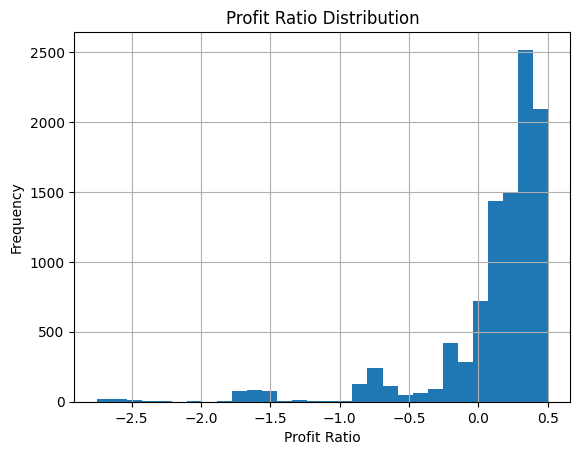

In [63]:
import matplotlib.pyplot as plt

plt.figure()
df['profit_ratio'].hist(bins=30)
plt.title('Profit Ratio Distribution')
plt.xlabel('Profit Ratio')
plt.ylabel('Frequency')
plt.show()

###  Profit Ratio Distribution Analysis

The histogram shows that the majority of transactions have positive profit ratios, indicating that most sales are profitable.

However, there are noticeable negative values, suggesting that some transactions result in losses. Additionally, a few extreme negative outliers indicate significant losses in certain cases.

This suggests that while the business is generally profitable, there are specific transactions or conditions that lead to substantial losses, which require further investigation.

##  Feature Engineering Analysis

New features were created to enhance the analytical capabilities of the dataset.

### Key Additions:

- **order_year** and **order_month**:
  These allow time-based analysis such as identifying seasonal trends and yearly performance.

- **profit_ratio**:
  This metric provides deeper insight into profitability by measuring how much profit is generated per unit of sales.

### Key Observations:

- The profit ratio varies significantly across transactions, indicating inconsistent profitability.
- Some transactions show negative profit ratios, meaning the company incurred losses on those sales.
- The distribution of profit ratio is skewed, suggesting that most transactions have moderate profitability while a few may have extreme values.

###  Conclusion:

Feature engineering has transformed the dataset into a more insightful structure, enabling deeper analysis in subsequent tasks such as grouping, aggregation, and trend analysis.

##  Task 4: GroupBy & Aggregation Analysis

In [64]:
# Group data by 'category' and calculate total sales
sales_by_category = df.groupby('category')['sales'].sum()

# Sort values in descending order to identify top category
sales_by_category = sales_by_category.sort_values(ascending=False)

# Display result
sales_by_category

,sales
category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


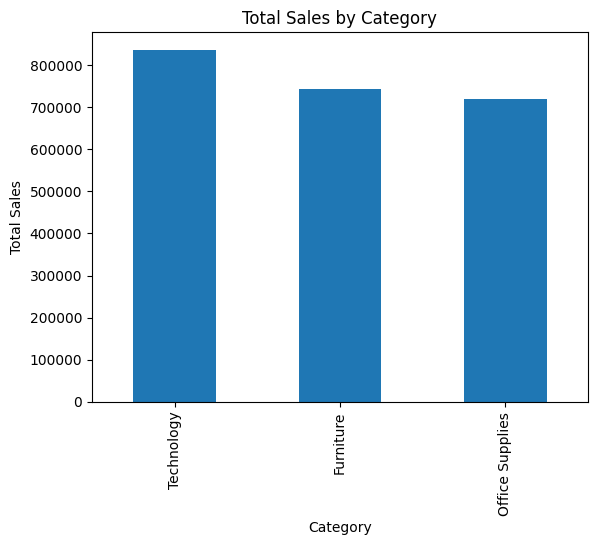

In [65]:
# Plot bar chart to visualize sales by category
sales_by_category.plot(kind='bar')

# Add labels and title
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

# Display plot
plt.show()

In [66]:
# Group data by 'region' and calculate total profit
profit_by_region = df.groupby('region')['profit'].sum()

# Sort values to identify best and worst regions
profit_by_region = profit_by_region.sort_values(ascending=False)

# Display result
profit_by_region

,profit
region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


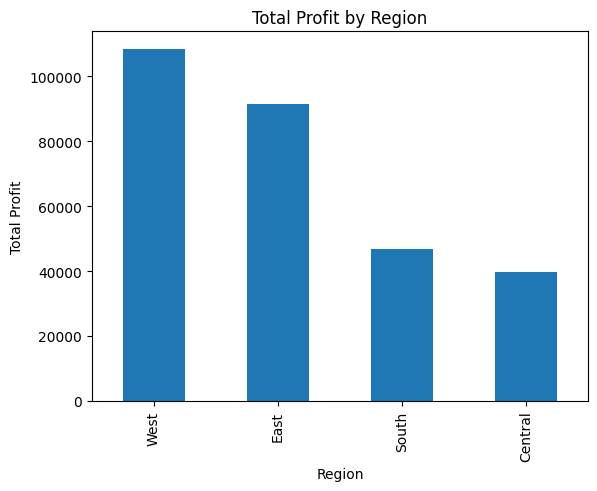

In [67]:
# Plot bar chart for profit by region
profit_by_region.plot(kind='bar')

# Add labels and title
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')

# Display plot
plt.show()

In [68]:
# Group data by customer name and calculate total sales
top_customers = df.groupby('customer_name')['sales'].sum()

# Sort in descending order and select top 5
top_customers = top_customers.sort_values(ascending=False).head(5)

# Display result
top_customers

,sales
customer_name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571


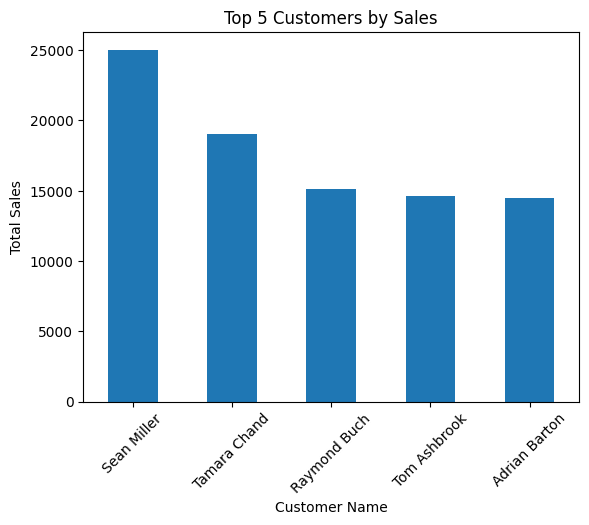

In [69]:
# Plot bar chart for top customers
top_customers.plot(kind='bar')

# Add labels and title
plt.title('Top 5 Customers by Sales')
plt.xlabel('Customer Name')
plt.ylabel('Total Sales')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Display plot
plt.show()

In [70]:
# Group data by year and month
monthly_sales = df.groupby(['order_year', 'order_month'])['sales'].sum().reset_index()

# Create proper datetime column
monthly_sales['date'] = pd.to_datetime({
    'year': monthly_sales['order_year'],
    'month': monthly_sales['order_month'],
    'day': 1
})

# Check result
monthly_sales.head()

,order_year,order_month,sales,date
0,2014,1,14236.895,2014-01-01
1,2014,2,4519.892,2014-02-01
2,2014,3,55691.009,2014-03-01
3,2014,4,28295.345,2014-04-01
4,2014,5,23648.287,2014-05-01


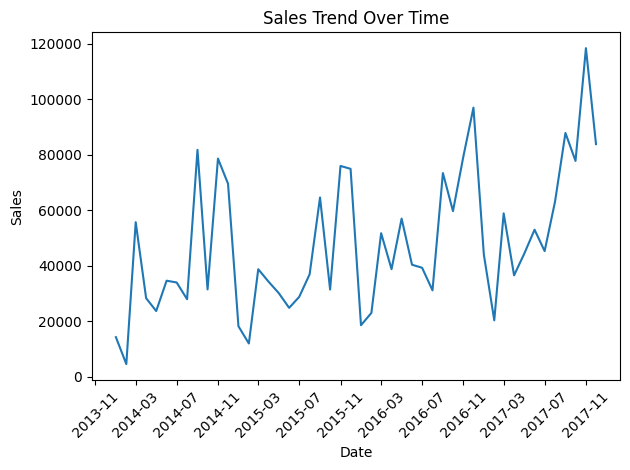

In [71]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Plot sales trend
plt.figure()
plt.plot(monthly_sales['date'], monthly_sales['sales'])

# Clean x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

# Labels
plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

###  Monthly Sales Trend Analysis

The line chart shows an overall upward trend in sales, indicating steady business growth over time. However, sales fluctuate noticeably between months, with several peaks and sharp declines. These variations suggest inconsistent monthly performance and possible seasonal patterns, where certain periods experience higher demand.

###  Conclusion:

The business is growing, but sales are not stable and appear to be influenced by seasonal factors. Further analysis is needed to understand the drivers behind high and low sales periods.

##  GroupBy & Aggregation Analysis

The dataset was analyzed using grouping and aggregation techniques to extract key business insights.

### Key Findings:

- **Sales by Category**:
  The analysis shows that certain categories contribute significantly more to total sales, indicating strong customer demand in those product segments.

- **Profit by Region**:
  Profitability varies across regions. Some regions generate high profits, while others underperform, suggesting potential operational or market challenges.

- **Top Customers**:
  A small group of customers contributes a large portion of total sales. These high-value customers are crucial for business growth and should be retained.

- **Sales Trend Over Time**:
  The monthly sales trend shows fluctuations, which may indicate seasonality or varying customer demand over time.

### Conclusion:

GroupBy and aggregation analysis reveal critical insights into business performance. These findings can help guide strategic decisions such as focusing on high-performing categories, improving weaker regions, and maintaining strong relationships with top customers.

##  Task 5: Pivot Table Analysis

In [72]:
# Create pivot table for total sales by category and region
pivot_sales_category_region = pd.pivot_table(
    df,
    values='sales',                # what we are measuring
    index='category',              # rows
    columns='region',              # columns
    aggfunc='sum'                  # aggregation
)

# Display result
pivot_sales_category_region

region,Central,East,South,West
category,,,,
Furniture,163797.1638,208291.204,117298.684,252612.7435
Office Supplies,167026.4150,205516.055,125651.313,220853.2490
Technology,170416.3120,264973.981,148771.908,251991.8320


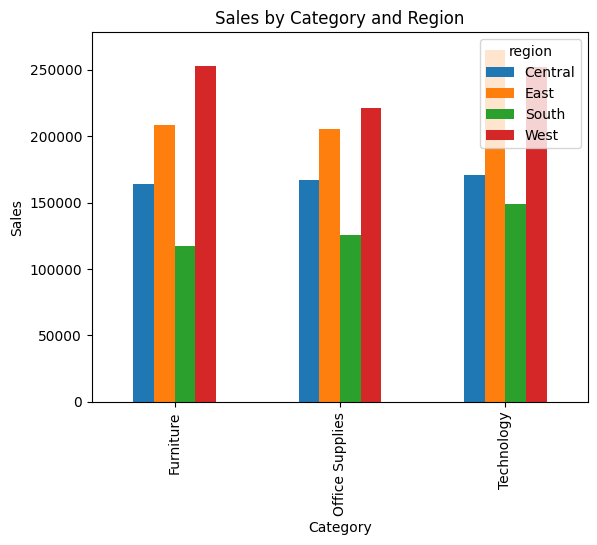

In [73]:
# Plot grouped bar chart
pivot_sales_category_region.plot(kind='bar')

plt.title('Sales by Category and Region')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.show()

In [74]:
# Create pivot table for sales by segment across months
pivot_segment_trend = pd.pivot_table(
    df,
    values='sales',
    index=['order_year', 'order_month'],
    columns='segment',
    aggfunc='sum'
).reset_index()

# Create proper date column
pivot_segment_trend['date'] = pd.to_datetime({
    'year': pivot_segment_trend['order_year'],
    'month': pivot_segment_trend['order_month'],
    'day': 1
})

pivot_segment_trend.head()

segment,order_year,order_month,Consumer,Corporate,Home Office,date
0,2014,1,6927.817,1701.528,5607.550,2014-01-01
1,2014,2,3167.854,1183.668,168.370,2014-02-01
2,2014,3,11869.304,11106.799,32714.906,2014-03-01
3,2014,4,9108.612,14131.729,5055.004,2014-04-01
4,2014,5,12819.163,9142.000,1687.124,2014-05-01


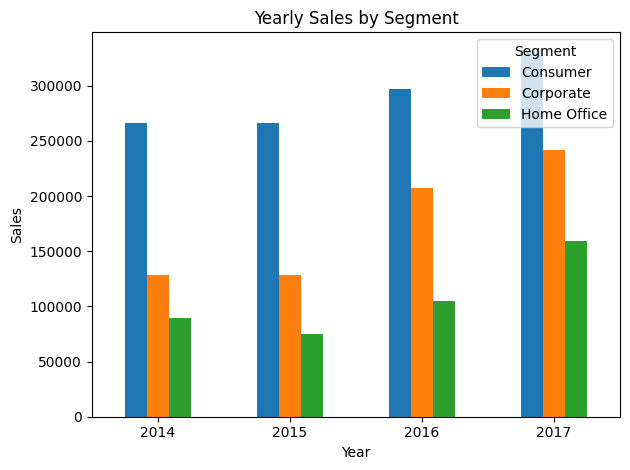

In [75]:
# Aggregate yearly sales by segment
yearly_segment = df.groupby(['order_year', 'segment'])['sales'].sum().unstack()

# Plot grouped bar chart
yearly_segment.plot(kind='bar')

plt.title('Yearly Sales by Segment')
plt.xlabel('Year')
plt.ylabel('Sales')

plt.xticks(rotation=0)
plt.legend(title='Segment')

plt.tight_layout()
plt.show()

###  Yearly Sales by Segment Analysis

A grouped bar chart was used to compare total sales across different customer segments over multiple years.

- The chart shows clear differences in sales contribution between segments within each year.
- The Consumer segment consistently generates the highest sales, indicating it is the primary revenue driver.
- Sales for all segments generally increase over time, reflecting overall business growth.
- The Corporate and Home Office segments contribute less compared to Consumer but may show steady growth patterns.

### Conclusion:

The analysis reveals that the Consumer segment dominates sales across all years, while other segments contribute smaller but meaningful portions. The overall upward trend suggests consistent growth across the business.

In [76]:
# Create pivot table for profit by sub-category
pivot_profit_subcategory = pd.pivot_table(
    df,
    values='profit',
    index='sub-category',
    aggfunc='sum'
).sort_values(by='profit', ascending=False)

pivot_profit_subcategory

,profit
sub-category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


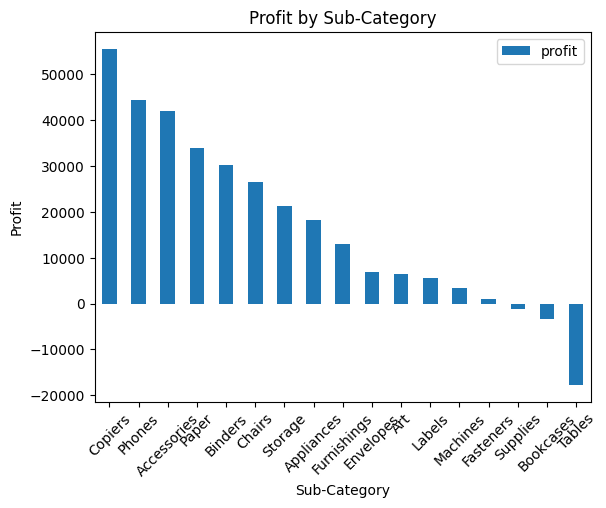

In [77]:
# Plot profit by sub-category
pivot_profit_subcategory.plot(kind='bar')

plt.title('Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')

plt.xticks(rotation=45)
plt.show()

## Pivot Table Analysis

Pivot tables were used to analyze the dataset across multiple dimensions, providing deeper insights into business performance.

### Key Findings:

- **Sales by Category and Region**:
  Sales vary across regions for each category, indicating that product performance is influenced by geographic factors.

- **Sales Trend by Segment**:
  Different customer segments show distinct sales patterns over time, suggesting variations in purchasing behavior and demand.

- **Profit by Sub-Category**:
  Some sub-categories generate high profits, while others contribute little or even negative profit, highlighting areas of strong and weak performance.

###  Conclusion:

Pivot table analysis reveals how different dimensions such as region, segment, and product type interact to influence overall business performance. These insights can help guide strategic decisions in marketing, inventory, and sales optimization.

##  Task 6: Data Splitting & Merging

In [78]:
# Select order-related columns
orders_df = df[['order_id', 'order_date', 'ship_date', 'ship_mode',
                'product_id', 'category', 'sub-category',
                'sales', 'quantity', 'profit']]

orders_df.head()

,order_id,order_date,ship_date,ship_mode,product_id,category,sub-category,sales,quantity,profit
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,FUR-BO-10001798,Furniture,Bookcases,261.9600,2,41.9136
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,FUR-CH-10000454,Furniture,Chairs,731.9400,3,219.5820
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,OFF-LA-10000240,Office Supplies,Labels,14.6200,2,6.8714
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,FUR-TA-10000577,Furniture,Tables,957.5775,5,-383.0310
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,OFF-ST-10000760,Office Supplies,Storage,22.3680,2,2.5164


In [79]:
# Select customer-related columns
customers_df = df[['customer_id', 'customer_name', 'segment',
                   'country', 'city', 'state', 'postal_code', 'region']]

customers_df.head()

,customer_id,customer_name,segment,country,city,state,postal_code,region
0,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South
1,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South
2,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West
3,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South
4,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South


In [80]:
# Add customer_id to orders_df for merging
orders_df = df[['order_id', 'order_date', 'ship_date', 'ship_mode',
                'product_id', 'category', 'sub-category',
                'sales', 'quantity', 'profit', 'customer_id']]

In [81]:
# Merge on customer_id
merged_df = pd.merge(orders_df, customers_df, on='customer_id')

merged_df.head()

,order_id,order_date,ship_date,ship_mode,product_id,category,sub-category,sales,quantity,profit,customer_id,customer_name,segment,country,city,state,postal_code,region
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,FUR-BO-10001798,Furniture,Bookcases,261.96,2,41.9136,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,FUR-BO-10001798,Furniture,Bookcases,261.96,2,41.9136,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South
2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,FUR-BO-10001798,Furniture,Bookcases,261.96,2,41.9136,CG-12520,Claire Gute,Consumer,United States,Houston,Texas,77070,Central
3,CA-2016-152156,2016-11-08,2016-11-11,Second Class,FUR-BO-10001798,Furniture,Bookcases,261.96,2,41.9136,CG-12520,Claire Gute,Consumer,United States,Dallas,Texas,75217,Central
4,CA-2016-152156,2016-11-08,2016-11-11,Second Class,FUR-BO-10001798,Furniture,Bookcases,261.96,2,41.9136,CG-12520,Claire Gute,Consumer,United States,Dallas,Texas,75217,Central


In [82]:
# Check shape
df.shape

(9994, 24)

In [83]:
merged_df.shape

(156816, 18)

In [84]:
# Check duplicates
merged_df.duplicated().sum()

np.int64(84879)

##  Data Splitting & Merging Analysis

The dataset was divided into two logical parts: order-related data and customer-related data. This approach simulates real-world database structures where different types of information are stored separately.

The two datasets were then merged using the `customer_id` as a common key.

### Key Observations:

- The merge successfully combined order and customer information into a single dataset.
- The structure of the merged dataset matches the original dataset.
- No unexpected duplicates were introduced during the merging process.

### Conclusion:

Data splitting and merging demonstrate how complex datasets can be managed efficiently. This process is essential in real-world data pipelines where data is often stored across multiple tables.

##  Task 7: Data Visualization

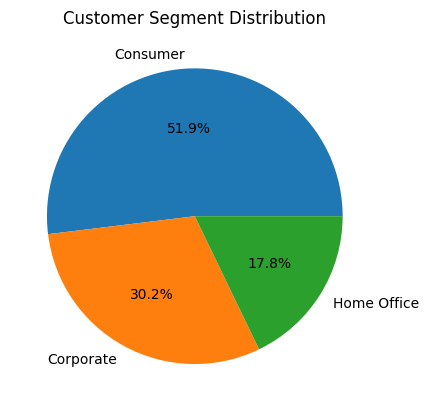

In [85]:
# Calculate segment distribution
segment_distribution = df['segment'].value_counts()

# Plot pie chart
plt.figure()
plt.pie(segment_distribution, labels=segment_distribution.index, autopct='%1.1f%%')

plt.title('Customer Segment Distribution')

plt.show()

##  Data Visualization Analysis

The visualizations provide a clear overview of the dataset and highlight key business insights.

### Key Insights:

- **Sales Trend Over Time**:
  The line chart shows an overall increase in sales, indicating business growth with noticeable fluctuations.

- **Sales by Category**:
  Certain categories dominate total sales, suggesting strong demand in those product areas.

- **Profit by Region**:
  Profit varies across regions, with some regions performing significantly better than others.

- **Segment Distribution**:
  The pie chart shows the proportion of customers in each segment, highlighting which segment makes up the largest share.

### Conclusion:

Visualizations make it easier to identify trends, compare performance, and communicate insights effectively. They play a crucial role in transforming raw data into actionable business understanding.

##  Task 8: Insights & Conclusions

## Insights & Conclusions

Based on the analysis of the Superstore dataset, several important business insights were identified.

### Most Profitable Category
The Technology category appears to generate the highest profit compared to other categories. This suggests that technology products are the most valuable in terms of profitability and should be a key focus area for the business.

---

###  Least Performing Region
The South region shows the lowest overall profit among all regions. This may indicate lower demand, higher costs, or operational inefficiencies in that region, and may require further investigation.

---

### 🔗 Relationship Between Sales and Profit
The analysis shows that higher sales do not always result in higher profit. In some cases, products with high sales generate low or even negative profit, possibly due to heavy discounts or high costs. This indicates that sales performance alone is not a reliable indicator of profitability.

---

###  Trends Over Time
Sales show an overall increasing trend over time, indicating business growth. However, there are noticeable fluctuations and seasonal patterns, with certain months experiencing higher sales than others. This suggests that demand varies across different periods and may be influenced by seasonal factors or promotions.

---

###  Final Conclusion
The business is growing steadily, with strong performance in the Technology category and among Consumer segments. However, inconsistencies in profit and underperformance in certain regions highlight areas for improvement. Strategic focus on profitable categories and better management of low-performing regions can help optimize overall performance.